<a href="https://colab.research.google.com/github/hajyhia/Airbnb_Berlin_Price_predic/blob/main/Airbnb_Berlin_Price_Predict_Data_Cleansing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install missingno
# !pip install geopy

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings

# Ignore warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
df_DC = pd.read_pickle('/content/drive/My Drive/Airbnb/df_DC.pkl')

In [7]:
df = df_DC.copy()

In [8]:
# df = df.drop(columns=['Listing ID','Host ID'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23460 entries, 0 to 23535
Data columns (total 39 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Listing ID                     23460 non-null  int64  
 1   Accomodates                    23460 non-null  float64
 2   Accuracy Rating                18862 non-null  float64
 3   Bathrooms                      23431 non-null  float64
 4   Bedrooms                       23440 non-null  float64
 5   Beds                           23426 non-null  float64
 6   Checkin Rating                 18844 non-null  float64
 7   Cleanliness Rating             18866 non-null  float64
 8   Communication Rating           18860 non-null  float64
 9   Guests Included                23460 non-null  float64
 10  Host Response Rate             12984 non-null  float64
 11  Latitude                       23460 non-null  float64
 12  Location Rating                18845 non-null  floa

## Defines data columns Lists

In [53]:
numerical_columns = ['Accomodates', 'Bathrooms', 'Bedrooms', 'Beds', 'Guests Included','Min Nights','Reviews','Price']
rating_columns = ['Value Rating','Location Rating', 'Cleanliness Rating','Checkin Rating','Accuracy Rating','Communication Rating','Host Response Rate','Overall Rating']
boolean_columns = ['Is Superhost','Is Exact Location', 'Instant Bookable']
categorical_columns = ['Room Type','Property Type Reduced','Neighborhood Group','Postal Code Reduced','Host Response Time'] # , 'Neighbourhood Grouped'
date_columns = ['review_date','Host Since']
non_categorical_columns = numerical_columns + rating_columns + boolean_columns

## Checking correlations among numerical features

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23460 entries, 0 to 23535
Data columns (total 39 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Listing ID                     23460 non-null  int64  
 1   Accomodates                    23460 non-null  float64
 2   Accuracy Rating                18862 non-null  float64
 3   Bathrooms                      23431 non-null  float64
 4   Bedrooms                       23440 non-null  float64
 5   Beds                           23426 non-null  float64
 6   Checkin Rating                 18844 non-null  float64
 7   Cleanliness Rating             18866 non-null  float64
 8   Communication Rating           18860 non-null  float64
 9   Guests Included                23460 non-null  float64
 10  Host Response Rate             12984 non-null  float64
 11  Latitude                       23460 non-null  float64
 12  Location Rating                18845 non-null  floa

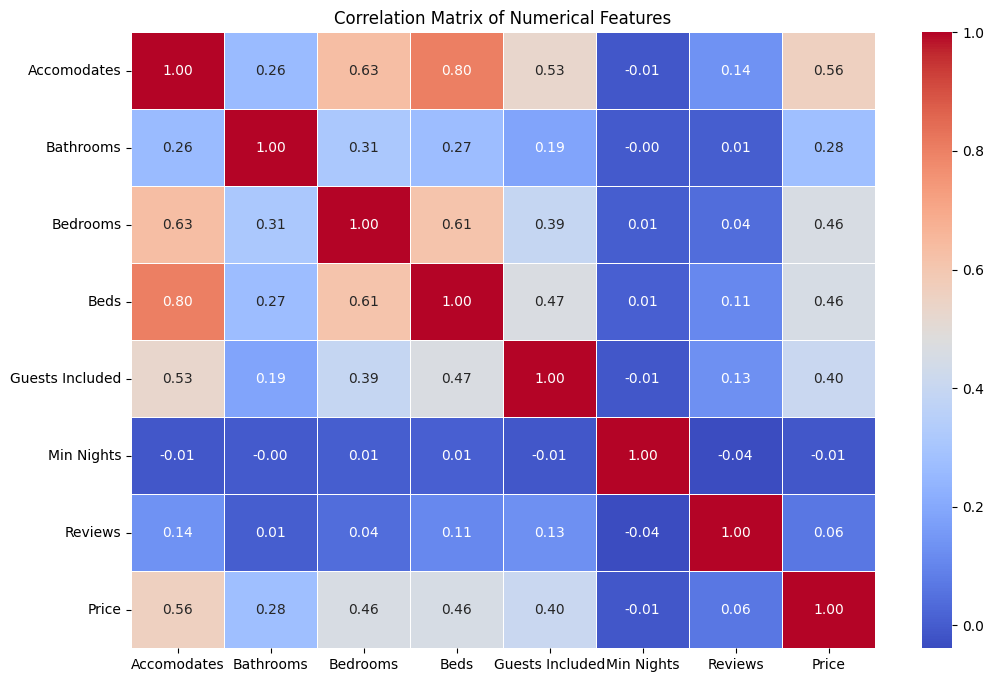

In [56]:
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [55]:
numerical_columns

['Accomodates',
 'Bathrooms',
 'Bedrooms',
 'Beds',
 'Guests Included',
 'Min Nights',
 'Reviews',
 'Price']

## Outliers

The box extends from the first quartile (Q1) to the third quartile (Q3) of the data, with a line at the median. The whiskers extend from the box to the farthest data point lying within 1.5x the inter-quartile range (IQR) from the box. Flier points are those past the end of the whiskers. See

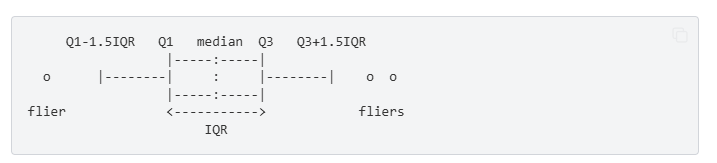

Target Value

In [57]:
outliers_columns = numerical_columns.copy()
outliers_columns.remove('Reviews')

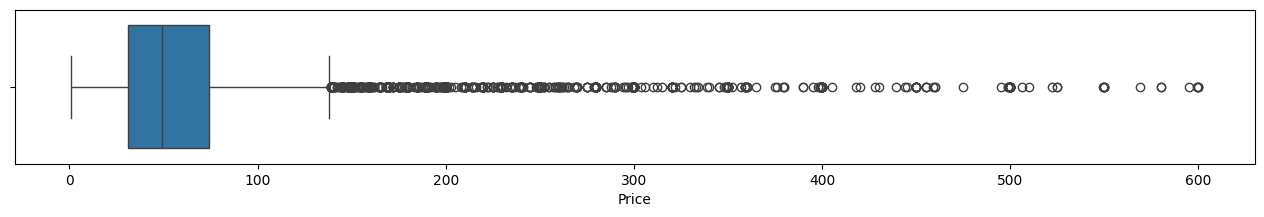

In [12]:
plt.figure(figsize=(16, 2))
sns.boxplot(df['Price'], orient='h')
plt.show()

In [60]:
df[numerical_columns].describe().loc[['min', '25%', '50%', '75%', 'max']].T

,min,25%,50%,75%,max
Accomodates,1.0,2.0,2.0,3.0,16.0
Bathrooms,0.0,1.0,1.0,1.0,8.5
Bedrooms,0.0,1.0,1.0,1.0,10.0
Beds,0.0,1.0,1.0,2.0,22.0
Guests Included,1.0,1.0,1.0,1.0,16.0
Min Nights,1.0,2.0,3.0,4.0,1000.0
Reviews,0.0,1.0,5.0,17.0,545.0
Price,1.0,31.0,49.0,74.0,600.0


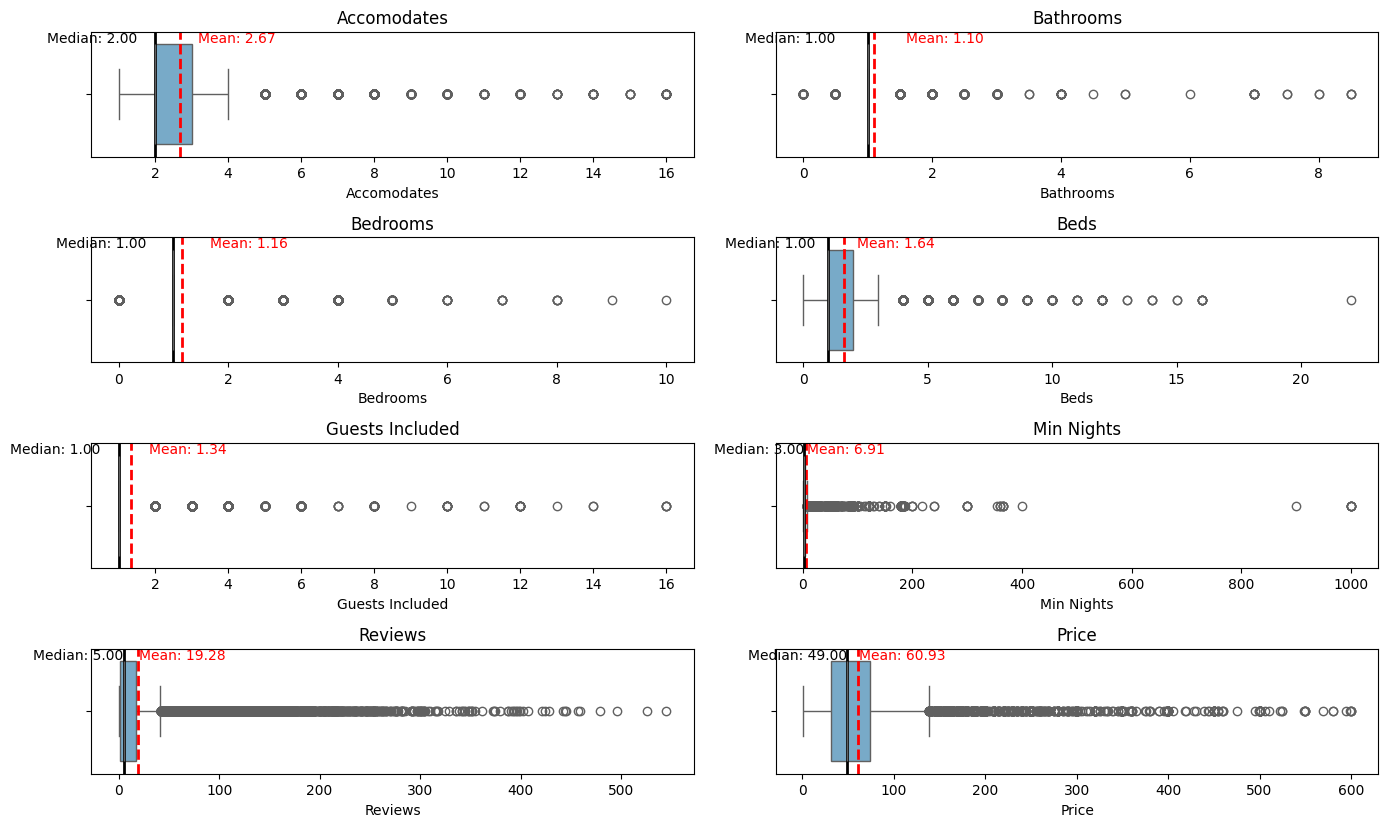

In [84]:
plt.figure(figsize=(14, 10))
for i, col in enumerate(numerical_columns, 1):
# for i, col in enumerate([c for c in numerical_columns if c not in ['Min Nights']], 1):
    mean_ = df[col].mean()
    median_ = df[col].median()
    plt.subplot(5, 2, i)
    sns.boxplot(x=df[col].dropna(), palette='Blues')
    plt.title(f"{col}")
    plt.axvline(mean_, color='red', linestyle='dashed', linewidth=2)
    plt.axvline(median_, color='black', linewidth=2)
    plt.text(mean_ + 0.5, -0.45, f'Mean: {mean_:.2f}', color='r', ha='left', va='center')
    plt.text(median_ - 0.5, -0.45, f'Median: {median_:.2f}', color='k', ha='right', va='center')
plt.tight_layout()
plt.show()

The boxplots reveal potential outliers in several numerical features, particularly:

1. Price: Likely contains extreme values (high-end listings or pricing errors).
2. Reviews: Some listings have significantly higher review counts than others.
3. Bedrooms, Bathrooms, Beds, Accommodates: Some properties might have unrealistic values (e.g., too many or too few bedrooms relative to accommodations).

In [81]:
def df_describe(df, numerical_columns):
  min_vals = []
  max_vals = []
  Q1_ = []
  Q2_ = []
  Q3_ = []
  IQR_ = []
  lower_bound_ = []
  upper_bound_ = []
  for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q2 = df[column].quantile(0.50)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    min_vals.append(df[column].min())
    max_vals.append(df[column].max())
    Q1_.append(Q1)
    Q2_.append(Q2)
    Q3_.append(Q3)
    IQR_.append(IQR)
    lower_bound_.append(lower_bound)
    upper_bound_.append(upper_bound)

  # return pd.DataFrame(data = [min_vals, lower_bound_,Q1_,Q2_,Q3_ ,IQR_,upper_bound_,max_vals],
  #            columns=["min_vals", "lower_bound","Q1","Q2","Q3","IQR","upper_bound","max_vals"])
  return pd.DataFrame({
      'min': min_vals,
      'Q1(25%)': Q1_,
      'Q2(50%)': Q2_,
      'Q3(75%)': Q3_,
      'max': max_vals,
      'IQR': IQR_,
      'lower_bound': lower_bound_,
      'upper_bound': upper_bound_}, index=numerical_columns)

df_describe(df, numerical_columns)

,min,Q1(25%),Q2(50%),Q3(75%),max,IQR,lower_bound,upper_bound
Accomodates,1.0,2.0,2.0,3.0,16.0,1.0,0.5,4.5
Bathrooms,0.0,1.0,1.0,1.0,8.5,0.0,1.0,1.0
Bedrooms,0.0,1.0,1.0,1.0,10.0,0.0,1.0,1.0
Beds,0.0,1.0,1.0,2.0,22.0,1.0,-0.5,3.5
Guests Included,1.0,1.0,1.0,1.0,16.0,0.0,1.0,1.0
Min Nights,1.0,2.0,3.0,4.0,1000.0,2.0,-1.0,7.0
Reviews,0.0,1.0,5.0,17.0,545.0,16.0,-23.0,41.0
Price,1.0,31.0,49.0,74.0,600.0,43.0,-33.5,138.5


### Outlier Removal

In [32]:
# Implementing Outlier Removal using the IQR Method
def remove_outliers(df, column):
    """Removes outliers based on IQR for a given column."""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Applying outlier removal to selected numerical columns
cleaned_df = df.copy()
for col in ["Price", "Reviews", "Bedrooms", "Bathrooms", "Beds", "Accomodates"]:
    cleaned_df = remove_outliers(cleaned_df, col)

# Displaying summary after outlier removal
cleaned_df

,Listing ID,Accomodates,Accuracy Rating,Bathrooms,Bedrooms,Beds,Checkin Rating,Cleanliness Rating,Communication Rating,Guests Included,Host Response Rate,Latitude,Location Rating,Longitude,Min Nights,Overall Rating,Price,Reviews,Value Rating,review_date,Comments,Host Since,Host Response Time,Is Superhost,neighbourhood,Neighborhood Group,Postal Code,Is Exact Location,Property Type,Room Type,Instant Bookable,Neighbourhood Grouped,Property Type Reduced,Postal Code Reduced,Room Type Encoded,Property Type Reduced Encoded,Neighborhood Group Encoded,Postal Code Reduced Encoded,Host Response Time Encoded
0,2695,2.0,10.0,1.0,1.0,1.0,10.0,10.0,10.0,1.0,50.0,52.54851,9.0,13.40455,2.0,100.0,17.0,7.0,10.0,07-04-18,I really enjoyed staying at Micha and Nadja's ...,09-16-08,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,Pankow,Apartment,10,1,0,6,0,1
20,35152,2.0,9.0,1.0,1.0,1.0,9.0,10.0,10.0,1.0,NaN,52.53506,9.0,13.39699,3.0,93.0,50.0,4.0,8.0,06-09-11,Great place and great host. The flat is very n...,06-24-10,None,False,Mitte,Mitte,10115,True,Loft,Private room,False,Mitte,Loft,10,1,9,4,0,4
28,41306,2.0,10.0,1.0,1.0,1.0,8.0,6.0,8.0,1.0,NaN,52.53028,10.0,13.42348,1.0,80.0,40.0,1.0,8.0,09-26-14,"nice experience, nice area, it was really cosy...",07-25-10,None,False,Prenzlauer Berg,Pankow,10405,True,Apartment,Private room,False,Pankow,Apartment,10,1,0,6,0,4
32,44083,2.0,9.0,1.0,1.0,1.0,9.0,9.0,10.0,2.0,90.0,52.49040,10.0,13.44085,2.0,85.0,42.0,13.0,9.0,01-05-11,The appartment was very nice and so the host \n,08-06-10,within a day,False,Alt-Treptow,Treptow - KÃ¶penick,12435,False,Apartment,Private room,False,Treptow - KÃ¶penick,Apartment,12,1,0,11,1,1
37,48955,2.0,NaN,1.0,1.0,1.0,NaN,NaN,NaN,1.0,0.0,52.53627,NaN,13.42081,4.0,NaN,70.0,0.0,NaN,None,None,08-24-10,a few days or more,False,Prenzlauer Berg,Pankow,10405,True,Apartment,Entire home/apt,False,Pankow,Apartment,10,0,0,6,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23522,34672106,2.0,NaN,1.0,1.0,1.0,NaN,NaN,NaN,2.0,NaN,52.63786,NaN,13.48578,2.0,NaN,55.0,0.0,NaN,None,None,02-10-13,None,False,Wedding,Pankow,13125,True,Apartment,Entire home/apt,False,Mitte,Apartment,13,0,0,6,2,4
23523,34672629,2.0,NaN,1.0,1.0,1.0,NaN,NaN,NaN,1.0,NaN,52.47889,NaN,13.42417,2.0,NaN,45.0,0.0,NaN,None,None,09-13-17,None,True,NeukÃ¶lln,NeukÃ¶lln,12049,True,Apartment,Private room,False,NeukÃ¶lln,Apartment,12,1,0,5,1,4
23525,34674496,2.0,NaN,1.0,1.0,1.0,NaN,NaN,NaN,1.0,67.0,52.48347,NaN,13.44115,4.0,NaN,75.0,0.0,NaN,None,None,09-15-16,within a few hours,False,NeukÃ¶lln,NeukÃ¶lln,12045,True,Apartment,Entire home/apt,True,NeukÃ¶lln,Apartment,12,0,0,5,1,2
23526,34675305,2.0,NaN,1.0,1.0,1.0,NaN,NaN,NaN,1.0,NaN,52.52829,NaN,13.44483,14.0,NaN,70.0,0.0,NaN,None,None,09-20-17,None,False,Friedrichshain,Friedrichshain-Kreuzberg,10407,True,Apartment,Entire home/apt,False,Friedrichshain-Kreuzberg,Apartment,10,0,0,1,0,4


## Save state

In [ ]:
# df.to_pickle("/content/drive/My Drive/Airbnb/df_DC.pkl")

In [ ]:
# cleaned_df = pd.read_pickle('/content/drive/My Drive/Airbnb/df_DC.pkl')
# cleaned_df.info()